# CNN para classificação de imagens

Problema de classificação usando a base de dados MNIST (dígitos manuscritos).

O dataset MNIST contém 60.000 imagens para treino e 10.000 para teste, cada uma com 28×28 pixels, representando os dígitos de 0 a 9.

## 1. Importando as bibliotecas

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np

## 2. Carregando o dataset

In [ ]:
# O TensorFlow já possui o dataset disponível para download automático
# Cada imagem possui dimensão 28x28 e um rótulo entre 0 e 9

(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

In [ ]:
x_train.shape

(60000, 28, 28)

In [ ]:
x_test.shape

(10000, 28, 28)

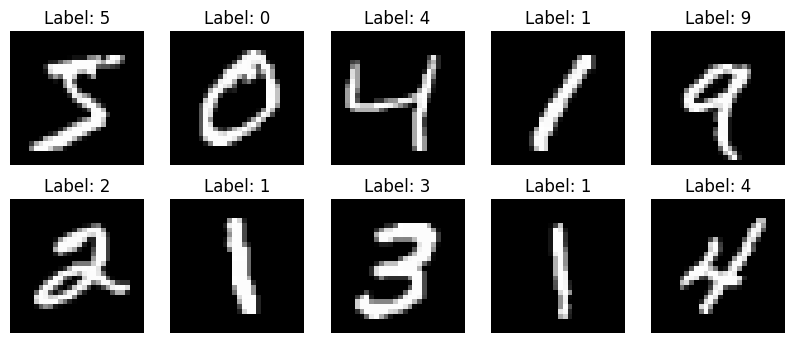

In [ ]:
plt.figure(figsize=(10,4))  # size of the figure

for i in range(10):
    plt.subplot(2,5,i+1)    # create a grid with 2 rows and 5 columns
    plt.imshow(x_train[i], cmap='gray')  # show image
    plt.title("Label: {}".format(y_train[i]))  # show the true digit
    plt.axis('off')  # remove axis for better visualization

plt.show()

## 3. Pré-processamento dos dados

In [ ]:
# Normalizamos os valores dos pixels para o intervalo [0,1]
# Isso melhora a estabilidade do treinamento

x_train = x_train / 255.0
x_test = x_test / 255.0

As linhas abaixo adicionam uma nova dimensão (canal) às imagens.

Por as imagens serem em tons de cinza, elas têm dimensão: 28x28 e não necessitam de uma terceira dimensão.

Porém, a camada `conv2D` do tensorflow espera entradas no formato:
```python
(altura, largura, canais)
```

In [ ]:
x_train = x_train[..., None]
x_test = x_test[..., None]

## 4. Construção da rede convolucional (CNN)

Essa rede neural terá:
+ Uma camada de entrada
+ Duas camadas convolucionais 2D seguidas por camadas de max pooling
+ Uma camada de achatamento
+ Uma camada densa (oculta)
+ Uma camada densa de saída

In [ ]:
# Sequential significa que as camadas são empilhadas uma após a outra e que a informação passa de forma direta, da entrada para a saída.
model = keras.Sequential([

    # Define a entrada da rede: imagem 28x28x1
    layers.Input(shape=(28, 28, 1)),

    # Camada de convolução 1: 32 filtros de tamanho 3x3 e stride de 1 posição (padrão) com ativação ReLU.
    layers.Conv2D(32, (3,3), activation='relu'),

    # Subamostragem: campo receptivo de 2x2 pixels: seleciona o maior valor destes 4 valores e stride igual a 2 (por padrão é o mesmo tamanho do pool size)
    layers.MaxPooling2D((2,2)),

    # Camada de convolução 2: 64 filtros de tamanho 3x3 e stride de 1 posição (padrão) com ativação ReLU.
    layers.Conv2D(64, (3,3), activation='relu'),

    # Subamostragem: campo receptivo de 2x2 pixels: seleciona o maior valor destes 4 valores e stride igual a 2 (por padrão é o mesmo tamanho do pool size)
    layers.MaxPooling2D((2,2)),

    # Camada de achatamento
    layers.Flatten(),

    # Camada densa de classificação
    layers.Dense(128, activation='relu'),

    # Camada de saída
    # 10 neurônios → um para cada classe (0 a 9)
    # Softmax transforma a saída em probabilidades
    layers.Dense(10, activation='softmax')
])

## 5. Compilando o modelo

In [ ]:
# optimizer → algoritmo que atualiza os pesos
# loss → função de erro para classificação multiclasse
# metrics → métricas de avaliação

model.compile(
    optimizer='sgd',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## 6. Treinamento da rede

**OBS**.: Estamos usando GPU.

In [ ]:
# epochs → quantas vezes o dataset será usado no treinamento
# batch_size → quantidade de amostras usadas para se calcular o vetor gradiente

model.fit(
    x_train,
    y_train,
    epochs=15,
    batch_size=32
)

Epoch 1/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8456 - loss: 0.5434
Epoch 2/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9573 - loss: 0.1418
Epoch 3/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9702 - loss: 0.0986
Epoch 4/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9760 - loss: 0.0794
Epoch 5/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9796 - loss: 0.0673
Epoch 6/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9821 - loss: 0.0581
Epoch 7/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9841 - loss: 0.0515
Epoch 8/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9853 - loss: 0.0470
Epoch 9/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9877 - loss: 0.0421
Epoch 10/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9881 - loss: 0.0384
Epoch 11/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9889 - loss: 0.0357
Epoch 12/15
1875/1875 ━━━━━━━━

## 7. Avaliação do modelo

In [ ]:
train_loss, train_accuracy = model.evaluate(x_train, y_train)

print("Acurácia no conjunto de treinamento:", train_accuracy)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9905 - loss: 0.0288
Acurácia no conjunto de treinamento: 0.9905166625976562


In [ ]:
# Testamos o modelo usando dados que ele nunca viu

test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("Acurácia no conjunto de teste:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9869 - loss: 0.0396
Acurácia no conjunto de teste: 0.9868999719619751


## 8. Fazer previsões com a rede

In [ ]:
# Pegamos algumas imagens do conjunto de teste
# No caso abaixo, o método predict retorna uma matriz com 5 linhas e 10 colunas
# Cada linha contém as probabilidades para cada uma das 10 classes para uma imagem de entrada
predictions = model.predict(x_test[:5])

print("Probabilidades previstas para cada classe:")
print(predictions)

# Classe prevista (maior probabilidade)
predicted_classes = np.argmax(predictions, axis=1)

print("\nClasses previstas:", predicted_classes)

print('Classes esperadas:', y_test[:5])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step
Probabilidades previstas para cada classe:
[[5.5594421e-07 1.2866246e-06 2.5280309e-05 3.0823192e-06 2.1599006e-11
  2.6880415e-10 5.0042918e-13 9.9996436e-01 1.1031289e-08 5.5289961e-06]
 [4.7012445e-08 4.9127912e-06 9.9999499e-01 1.9013329e-09 1.4889271e-13
  7.9767741e-13 6.2678024e-10 8.0117571e-12 8.7322588e-10 1.0880428e-14]
 [4.1189755e-06 9.9994755e-01 2.4799426e-06 9.0715197e-08 1.0885970e-05
  7.7078184e-08 9.2169685e-06 1.0939025e-05 1.4115088e-05 4.2859961e-07]
 [9.9987864e-01 4.4831530e-08 1.1335517e-05 9.2165964e-10 4.9199503e-08
  5.7497971e-07 1.0891103e-04 1.1500527e-07 1.6668518e-09 3.6963803e-07]
 [1.7964467e-08 8.5545958e-07 5.8574153e-07 5.4833205e-08 9.9538851e-01
  2.9007603e-08 1.4976404e-06 6.3747302e-06 1.7769559e-06 4.6002008e-03]]

Classes previstas: [7 2 1 0 4]
Classes esperadas: [7 2 1 0 4]
